# run all neccessary functionalities

In [4]:


def extract_stock_data(df, tdickers, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    #df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print()
            #print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print()
               # print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



In [5]:


def extract_spy_data(df, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    df_filtered = df.loc[start:end]
    return df_filtered



In [6]:
def get_spy2(start, end, t1, rebal_freq):
    ### Get tickers + setup
    global tickers, spy

    new_monthly_data1 = new_monthly_data.copy()
    new_monthly_data1.index = pd.to_datetime(new_monthly_data1.index)
    if rebal_freq == "m" or rebal_freq == "drm":
        spy_year2 = pd.to_datetime(t1).year
        spy_year1 = min(
            (pd.to_datetime(t1) - relativedelta(months=1)).year, 2026
        )  # Universe selection year (currently max 2025)
    elif rebal_freq == "y" or rebal_freq == "dry":
        spy_year2 = pd.to_datetime(t1).year
        spy_year1 = min(
            (pd.datetime(t1) - relativedelta(years=1)).year, 2026
        )  # Universe selection year (currently max 2025)
    # ensure sp500 membership
    # print(f'{spy_year1}:{spy_year2}')
    universe_year = spy_yoy_tickers.loc[str(spy_year1) : str(spy_year2)]
    if len(universe_year) > 0:
        candidate_universe = set(universe_year.iloc[0].dropna())
    else:
        candidate_universe = set()

    candidate_universe = list(candidate_universe.intersection(new_monthly_data.columns))
    # ensure tickers are not NA in regression period (typically 3 years)
    end_reg = str(pd.to_datetime(t1) + relativedelta(months=1))
    regression_window = new_monthly_data.loc[start:end_reg, candidate_universe]
    valid_tickers = regression_window.columns[
        ~regression_window.isna().any(axis=0)
    ].tolist()

    tickers = valid_tickers
    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data, tickers, start=start, end=end)

    # Assign equal weight as base weights
    base_w = {k: 1 / len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient="index", columns=["Weight"])

    spy = extract_spy_data(indexgspc, start, end)
    if monthly_data.index.equals(spy.index) == True:
        for i, j in monthly_data.iterrows():
            monthly_data.loc[i, "SP_500"] = spy.loc[i, "SP_500"]

    # Adjusting tickers list
    tickers = list(monthly_data.columns[:-1])

In [7]:
def download_with_retry(tickers, start, end, retries=3, delay=5):
    for attempt in range(retries):
        try:
            return extract_stock_data(new_monthly_data,tickers, start=start, end=end)
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(delay)
    raise Exception(f"Failed to download data after {retries} attempts.")




In [8]:
def famafrenchreturns():
    global ff3_monthly
    # Fama French Monthly Returns Data using getFamaFrenchFactors module
    ff3_monthly = gff.famaFrench3Factor(frequency="m")
    ff3_monthly.rename(columns={"date_ff_factors": "Date"}, inplace=True)
    ff3_monthly.set_index("Date", inplace=True)
    ff3_monthly.index = ff3_monthly.index.to_period("M").to_timestamp("D")
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.reindex(new_monthly_data.index).dropna()
    # Keeping Only the Dates in the monthly_data
    est_df = estimate_ff3_from_holdings(
        new_monthly_data, ff3_monthly.index[-1], ff3_monthly
    )
    ff3_monthly = pd.concat([ff3_monthly, est_df])


In [9]:
def estimate_ff3_from_holdings(new_monthly_data, last_known_date, ff3_source):
    # Filter for dates after the last known date
    returns_subset = new_monthly_data[new_monthly_data.index > last_known_date].copy()

    if returns_subset.empty:
        return None

    results = []

    # Get the last available RF rate as a fallback
    last_rf = ff3_source["RF"].iloc[-1]

    for date, row in returns_subset.iterrows():
        r = row.dropna()
        if r.empty:
            continue

        # --- [NEW] Get the RF Rate ---
        # Try to find the exact date in your ff3_monthly data
        if date in ff3_source.index:
            rf = ff3_source.loc[date, "RF"]
        else:
            rf = last_rf  # Use latest known rate if predicting for future dates

        n = len(r)
        tickers = r.index.tolist()
        hist = new_monthly_data[tickers].loc[:date].iloc[:-1]

        if hist.empty:
            continue

        cum_ret = hist.add(1).prod() - 1
        size_rank = cum_ret.rank(ascending=True)

        if len(hist) >= 12:
            prior_12m = hist.iloc[-12:].add(1).prod() - 1
        else:
            prior_12m = cum_ret

        value_rank = prior_12m.rank(ascending=True)

        small = r[size_rank <= n / 3].mean()
        big = r[size_rank >= 2 * n / 3].mean()
        smb = small - big

        high = r[value_rank <= n / 3].mean()
        low = r[value_rank >= 2 * n / 3].mean()
        hml = high - low

        # --- [ADJUSTED] Mkt-RF Calculation ---
        # Excess market return = Average stock return - Risk Free Rate
        mkt_rf = r.mean() - rf

        results.append(
            {
                "Date": date,
                "Mkt-RF": mkt_rf,
                "SMB": smb,
                "HML": hml,
                "RF": rf,  # Adding the RF to the output for completeness
            }
        )

    if not results:
        return None

    est = pd.DataFrame(results).set_index("Date")
    return est

In [10]:
def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [11]:
def to_cal_stock_price(startt,endd):
    global stock_price
    global s_price
    global s_keys
    global s_values
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = extract_stock_data(price_monthly_data,tickers,start=startt,end=endd)
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [12]:
def Transaction_Costs(initialize=False):
    # if initialize:
    #     print("first draw:", np.random.random())

    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    values = list(random.uniform(.01, .02) for i in range(len(tickers)))
    for key, value in zip(keys, values):
        t_cost[key] = value


In [13]:
def extract_weights(c_portf):   
    c_portf.index = c_portf['Ticker']
    if B%100000==0:
        c_portf['Weight'] = c_portf['Value']/B   
        return c_portf[['Weight']].astype(float)
    
    asof = pd.to_datetime(end).to_period('M').to_timestamp()
    tickers1 = c_portf.index.tolist()
    c_portf_ret = new_monthly_data[tickers1].loc[asof].astype(float) + 1

    # Ensure alignment by setting the index explicitly

    c_portf_ret.index = c_portf.index

    # Update values with returns
    c_portf['Value'] = c_portf['Value'].astype(float) * c_portf_ret

    # Calculate weights
    raw_weights = c_portf['Value'] / B
    total_w = raw_weights.sum()

    if total_w > 1.0:
        c_portf['Weight'] = raw_weights / total_w
    else:
        c_portf['Weight'] = raw_weights
    constrained_weights = c_portf[['Weight']].astype(float)

    if constrained_weights['Weight'].sum() > 1 + 1e-9:  # Added tolerance
        raise ValueError(f"Invalid weight(s) > 1: sum = {constrained_weights['Weight'].sum()}")

    return constrained_weights

In [ ]:
def optimization(c_portf):#new

    new_seed = np.random.randint(0, 1_000_000_000, dtype=int)
    np.random.seed(new_seed)
    random.seed(int(new_seed))
    global index, wei, aux, err, binary
    if c_portf is not None : # if we arent sending None, then this runs
        constrained_weigths = extract_weights(c_portf)

    # --- Local, cached index sets ---
    T = list(monthly_data.index)
    I = list(tickers)

    # --- Precompute numeric arrays (NO pandas .loc inside loops) ---
    # Align everything explicitly on T and I
    rf  = ff3_monthly.loc[T, "RF"].to_numpy(dtype=float)
    mkt = ff3_monthly.loc[T, "Mkt-RF"].to_numpy(dtype=float)
    smb = ff3_monthly.loc[T, "SMB"].to_numpy(dtype=float)
    hml = ff3_monthly.loc[T, "HML"].to_numpy(dtype=float)

    # Excess returns matrix X[t,i] = monthly_data[t,i] - RF[t]
    X = monthly_data.loc[T, I].to_numpy(dtype=float) - rf[:, None]

    # RHS[t] = mkt_opt*Mkt-RF + smb_opt*SMB + hml_opt*HML
    RHS = (mkt_opt * mkt) + (smb_opt * smb) + (hml_opt * hml)

    # Base weights and transaction-cost coefficients
    # base_weights[i] must be indexable by ticker
    base = {i: float(base_weights[i]) for i in I}
    # transaction cost coefficient per unit aux:
    # aux[i] * B * t_cost[i] / s_price[i]
    tc_coef = {i: float(B * t_cost[i] / s_price[i]) for i in I}

    # --- Build model ---
    index = LpProblem("Index", LpMinimize)

    wei    = LpVariable.dicts("Weight", I, lowBound=0)
    if c_portf is not None :   # if not setting none, we set lower weight bound to what the lower weight would be for the ticker owned 
        for i in I:            # Assumption: No personal buying or selling after portoflio starts, only prior
            if i in constrained_weigths.index:
                val = float(constrained_weigths.loc[i, 'Weight'])
                wei[i].lowBound = val
    aux    = LpVariable.dicts("Y",      I, lowBound=0)
    err    = LpVariable.dicts("Error",  T, lowBound=0)
    binary = LpVariable.dicts("bin",    I, cat=LpBinary)

    # Objective: minimize sum of absolute tracking errors
    index += lpSum(err[t] for t in T)

    # Weights sum to 1
    index += lpSum(wei[i] for i in I) == 1
    # Absolute deviation constraints + L1 bound
    for i in I:
        bw = base[i]
        index += aux[i] >= bw - wei[i]
        index += aux[i] >= wei[i] - bw
    index += lpSum(aux[i] for i in I) <= 1
    # Error term constraints: build portfolio return once per t
    for t_idx, t in enumerate(T):
        port = lpSum(wei[i] * X[t_idx, j] for j, i in enumerate(I))
        rhs  = float(RHS[t_idx])
        index += port - err[t] <= rhs
        index += port + err[t] >= rhs

    # Transaction cost constraint (no per-ticker tr_cost vars)
    index += lpSum(aux[i] * tc_coef[i] for i in I) <= B * 0.002 # I think?

    # Limit # of stocks in portfolio
    for i in I:
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in I) <= q
    # Solve (explicit CBC, quiet)
    index.solve(PULP_CBC_CMD(msg=False))

In [15]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [16]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [17]:
import time

def timed(name, fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    dt = time.perf_counter() - t0
    print(f"{name:25s} {dt:9.3f} s")
    return out

In [18]:
def simulator(beta1,beta2,beta3,begin,final,budget,number,c_portf,t1,rebal_freq):    
    global start
    global end
    start=begin
    end=t1 # instead of end, we need thte stock to not be NA in order to pull returns as well ...
    global mkt_bet, smb_bet, hml_bet
    mkt_bet, smb_bet, hml_bet = [],[],[]
    get_spy2(start, end,t1,rebal_freq)
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']

    # TARGET FACTOR BETAS
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 

    famafrenchreturns()
    to_cal_stock_price(start,end)
    Transaction_Costs()
    optimization(c_portf)
    others()
    global port_betas
    port_betas = portfolio_betas()
    mkt_bet.append(port_betas.iloc[0][2])
    smb_bet.append(port_betas.iloc[1][2])
    hml_bet.append(port_betas.iloc[2][2])


In [19]:
def out_of_sampless(cccc,dddd):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = cccc
    o1_end_d   = dddd
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,cccc,dddd)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [20]:
def out_of_sample():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    return oos1_new_performance

In [21]:
def out_of_sample():
    global oos1_daily_data,oos1_new_returns
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [22]:
def new_mod_out_of_sample1(hsahs,hsahs2):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = hsahs
    # last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = hsahs2
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [23]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [24]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [25]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    period_end = pd.to_datetime('2025-01-01')
    one_year_before = period_end - timedelta(days=365)
    os_start = period_end - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = period_end - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [26]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    period_end = today#pd.to_datetime('2025-01-01')

    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = period_end - timedelta(days=(365 * (os_years - year)))
        two_months_before = (out_of_sample_year_start[(year+1)] - relativedelta(months = period_end.month- 1))
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = period_end - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - relativedelta(months = period_end.month-1)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    
    inner_in_of_sample_year_start={}
    for year in range(in_years+os_years):
        inner_in_of_sample_year_start[(year+1)] = period_end - timedelta(days=(365 * (in_years+os_years - year)))
        two_months_before = inner_in_of_sample_year_start[(year+1)] - relativedelta(months = period_end.month-1)
        inner_in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=inner_in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        inner_in_of_sample_year_start[(year+1)]=inner_in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date
    print(out_of_sample_year_start)
    print(out_of_sample_year_end)
    print(in_of_sample_year_start)
    print(in_of_sample_year_end)
    return inner_in_of_sample_year_start

In [27]:
def new_run_with_backtest_rebalance_rlm(inyears,outyears,betaA,betaB,betaC, rebal_freq, adj):
    global start_date
    global end_date
    global os_years,tostorelist,nchecklist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    global inner_n_year_before_cal
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    global newbudget
    newbudget = 1000000
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,newbudget,50,None)
    global checklist
    global mchecklist
    checklist=[]
    mchecklist=[]
    tostorelist=[]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    os_count = 1        
    for k in range(os_years-adj): 
        global os_start
        global os_end
        global oos1_new_performances 
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]

        noos1_new_performance=pd.DataFrame()
        global checklist_1
        new_date_calculation()
        
        checking=out_of_sample()
        tostorelist.append(checking)
        inner_n_year_before=inner_n_year_before_cal[k+1]
        inner_n_year_after=str(pd.to_datetime(out_of_sample_year_end[k+1]) - relativedelta(years=1))
        # print('****************** Training Period: **********************')
        # print(inner_n_year_before)
        # print(inner_n_year_after)
        
        checklist.append(oos1_new_performance)
        
        if(rebal_freq == 'y'):
            
            newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]  
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500,None)
            rebalance_opt_weights.append(opt_weights)
            if(os_count == os_years-adj):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
            end_date = os_end 
        os_count +=1
    for kk in range(os_years-adj): 
        placeholder=noos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years-adj] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years-adj] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [28]:
def new_run_with_backtest_rebalance(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    global start_date
    global end_date
    global os_years,tostorelist,nchecklist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    global inner_n_year_before_cal
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    global newbudget
    newbudget = 1000000
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,newbudget,500,None)
    global checklist
    global mchecklist
    checklist=[]
    mchecklist=[]
    tostorelist=[]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    os_count = 1   
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performance
        oos1_new_performance={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]

        noos1_new_performance=pd.DataFrame()
        global checklist_1
        new_date_calculation()
        
        checking=out_of_sample()
        tostorelist.append(checking)
        inner_n_year_before=inner_n_year_before_cal[k+1]
        inner_n_year_after=out_of_sample_year_end[k+1]
        checklist.append(oos1_new_performance)
        
        if(rebal_freq == 'y'):
            if(k != 0):
                newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]  
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500,None)
            rebalance_opt_weights.append(opt_portf_weights)
            if(os_count == os_years):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if rebal_freq == 'dry':
            newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
            curr_year = pd.to_datetime(inner_n_year_after).year
            try:
                curr_df = pd.read_csv(f'Reward_CSVs_Surrogate/yrebal_explored_sortino_surrogate_{curr_year}.csv')
            except:
                print('File DNE')
            curr_df = curr_df.sort_values(by='reward')
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]
            print(f'{betaA}, {betaB}, {betaC} ')
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500,None)
            rebalance_opt_weights.append(opt_portf_weights)
            if(os_count == os_years):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
            end_date = os_end 
        os_count +=1
    for kk in range(os_years): 
        placeholder=noos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [29]:
def new_run_with_backtest_mrebalance_rlm(inyears,outyears,betaA,betaB,betaC, rebal_freq,adj,adj1):
    # Out years is set to +3 in the RLM, and the nit gets cut 5 years early
    # Effectively your using 2017-01-01 to 2019-12-31 data to check performance of 2017-2019... 
    global os_years
    global in_years
    global os_months
    os_years=outyears
    os_months = (inyears)*12
    print(' ')  
    print(' ')
    print(' ')  
    print(' ')
    print(f"########ADJ############{adj}")
    print(' ')  
    print(' ')
    print(' ')  
    print(' ')
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]

    #so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
    #to add to noos1_perf and to update budget    

    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance=pd.DataFrame()
    for k in range(os_months-1):
        k += adj1
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget    
        if(rebal_freq == 'm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k) - relativedelta(years=adj))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k) - relativedelta(years=adj))
            start_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50,None)
            
            print("**************Training*****************")
            print(n_year_before_updated)
            print(n_year_after_updated)
            print("**************Testing*****************")
            print(start_date1)
            print(end_date1)
            mperformance = out_of_sampless(start_date1,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
        
    return noos1_new_performance 
    
        
        

In [30]:
def new_run_with_backtest_mrebalance(inyears,outyears,betaA,betaB,betaC, starting_budget, rebal_freq,c_portf):
    global start_date
    global start_date1
    global end_date
    global os_years
    global in_years
    global os_months
    global mkt_bet, smb_bet, hml_bet

    mkt_bet,smb_bet,hml_bet = [],[],[]
    os_years=outyears
    os_months = os_years*12
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    inner_n_year_before_cal =new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance=pd.DataFrame()
    global expected_betas
    expected_betas = []

    for k in range(os_months-1):   
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget'
        if(rebal_freq == 'm'):
            print(k)
            print(n_year_before)
            print(n_year_after)
            n_year_before_updated = str(
                pd.to_datetime(n_year_before) + relativedelta(months=k)
            )
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            start_date11 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            expected_betas.append([betaA,betaB,betaC])
            # t1=
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,starting_budget*prev_month_perf,50,c_portf,rebal_freq,t1)
            rebalance_opt_weights.append(opt_portf_weights)
            mperformance = out_of_sampless(start_date11,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])

        if(rebal_freq == 'drm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            start_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            curr_year = (pd.to_datetime(n_year_after_updated)+relativedelta(months=1)).year 
            print(start_date1)
            try:
                # curr_df = pd.read_csv(f'Active_Strategy_CSVs/yrebal_explored_sortino_active_{curr_year}.csv')
                curr_df = pd.read_csv(f'Reward_CSVs_Surrogate/yrebal_explored_sortino_surrogate_{curr_year}.csv')    
                # curr_df = pd.read_csv(f'yrebal_explored_sortino_resample_surrogate_{curr_year}.csv')
                # curr_df = pd.read_csv(f'yrebal_explored_sortino_resample_surrogate_{pd.to_datetime(start_date1).date()}.csv')
            except FileNotFoundError:
                curr_df = pd.read_csv(f'yrebal_explored_sortino_resample_surrogate_2018-07-01.csv')  
                print('File DNE')
            curr_df = curr_df.sort_values(by='reward') 
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]

            print(f'{betaA}, {betaB}, {betaC} ')
            expected_betas.append([betaA,betaB,betaC])
            # t1 = 
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50,c_portf,rebal_freq,t1)
            rebalance_opt_weights.append(opt_portf_weights)

            mperformance = out_of_sampless(start_date1,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
    start_date= noos1_new_performance.index[0]
    end_date = noos1_new_performance.index[-1]

    return noos1_new_performance 

In [130]:
def new_run_with_backtest_mrebalance_front_end_rlm(
    target_date,
    inyears,
    outyears,
    betaA,
    betaB,
    betaC,
    starting_budget,
    rebal_freq,
):
    # front end target date is end of last month - one year(i.e., march 2026 is rn, feb-28-2025 is target date)

    global start_date
    global start_date1
    global end_date
    global os_years
    global in_years
    global os_months
    global mkt_bet, smb_bet, hml_bet

    mkt_bet, smb_bet, hml_bet = [], [], []
    os_years = outyears
    os_months = os_years*12
    in_years = inyears
    global performances
    performances = {}
    global spy_performances
    spy_performances = {}
    global new_performances
    new_performances = {}
    global new_spy_performances
    new_spy_performances = {}
    global n_year_before
    global n_year_after
    n_year_after = (
        target_date
        - relativedelta(months=inyears)
        + pd.offsets.MonthEnd(0)
    )
    anchor_date = (
        (target_date + pd.Timedelta(days=1))
        - relativedelta(months=inyears)
    )

    n_year_before = {
        1: (anchor_date - pd.DateOffset(years=3)).strftime("%Y-%m-%d"),
        2: (anchor_date - pd.DateOffset(years=2)).strftime("%Y-%m-%d"),
        3: (anchor_date - pd.DateOffset(years=1)).strftime("%Y-%m-%d"),
    }
    n_year_before = n_year_before[1]
    global rebalance_opt_weights
    global port_betas_list
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance = pd.DataFrame()
    global expected_betas
    expected_betas = []
    budget = starting_budget
    for k in range(
        inyears
    ):  # hard set to be equal to # of years of in data, walk forward to reduce overfitting
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget'
        if rebal_freq == "m":

            n_year_before_updated = str(
                pd.to_datetime(n_year_before) + relativedelta(months=k)
            )
            n_year_after_updated = str(
                pd.to_datetime(n_year_after) + relativedelta(months=k)
            )
            start_date11 = str(
                pd.to_datetime(n_year_before_updated) + relativedelta(months=36)
            )
            end_date1 = str(
                pd.to_datetime(n_year_before_updated) + relativedelta(months=37)
            )
            # print(f'Testing // Input Dates: {n_year_before_updated} - {n_year_after_updated}')
            # print(f'Validation  // Output Dates: {start_date11} - {end_date1}')
            expected_betas.append([betaA, betaB, betaC])
            budget = budget * prev_month_perf
            t1 = start_date11
            for attempt in range(3):
                try:
                    simulator(
                        betaA,
                        betaB,
                        betaC,
                        n_year_before_updated,
                        n_year_after_updated,
                        budget,
                        50,
                        None,
                        t1,
                        rebal_freq,
                    )
                    rebalance_opt_weights.append(opt_portf_weights)
                    mperformance = out_of_sampless(start_date11, end_date1).copy()
                    snipped_perf = mperformance.iloc[1]
                    break
                except IndexError:
                    if attempt == 2:
                        raise
            if k == 0:
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat(
                    [noos1_new_performance, first_perf.to_frame().T]
                )
            prev_month_perf = snipped_perf["Optimized Portfolio"]
            noos1_new_performance = pd.concat(
                [noos1_new_performance, snipped_perf.to_frame().T]
            )
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
    start_date = noos1_new_performance.index[0]
    end_date = noos1_new_performance.index[-1]

    return noos1_new_performance

In [ ]:
def new_run_with_backtest_mrebalance_front_end(
    target_date,inyears, outyears, betaA, betaB, betaC, starting_budget, rebal_freq, c_portf, obj_key
):
    # front end target date is end of last month (i.e., march 2026 is rn, feb-28-2026 is target date)
    global start_date
    global start_date1
    global end_date
    global os_years
    global in_years
    global os_months
    global mkt_bet, smb_bet, hml_bet

    mkt_bet, smb_bet, hml_bet = [], [], []
    os_years = outyears
    os_months = os_years * 12
    in_years = inyears
    global performances
    performances = {}
    global spy_performances
    spy_performances = {}
    global new_performances
    new_performances = {}
    global new_spy_performances
    new_spy_performances = {}
    global n_year_before
    global n_year_after
    n_year_after = target_date - relativedelta(years=outyears)
    anchor_date = (target_date + pd.Timedelta(days=1)) - pd.DateOffset(years=outyears)

    n_year_before = {
        1: (anchor_date - pd.DateOffset(years=3)).strftime("%Y-%m-%d"),
        2: (anchor_date - pd.DateOffset(years=2)).strftime("%Y-%m-%d"),
        3: (anchor_date - pd.DateOffset(years=1)).strftime("%Y-%m-%d"),
    }
    n_year_before = n_year_before[1]
    global rebalance_opt_weights
    global port_betas_list
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance = pd.DataFrame()
    global expected_betas
    expected_betas = []
    budget = starting_budget
    for k in range(os_months):

        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget'
        if rebal_freq == "m":

            n_year_before_updated = str(
                pd.to_datetime(n_year_before) + relativedelta(months=k)
            )
            n_year_after_updated = str(
                pd.to_datetime(n_year_after) + relativedelta(months=k)
            )
            start_date11 = str(
                pd.to_datetime(n_year_before_updated) + relativedelta(months=36)
            )
            end_date1 = str(
                pd.to_datetime(n_year_before_updated) + relativedelta(months=37)
            )

            expected_betas.append([betaA, betaB, betaC])
            budget = budget* prev_month_perf
            t1 = start_date11
            for attempt in range(3):
                try:
                    simulator(
                        betaA,
                        betaB,
                        betaC,
                        n_year_before_updated,
                        n_year_after_updated,
                        budget,
                        50,
                        c_portf,
                        t1,
                        rebal_freq,
                    )
                    rebalance_opt_weights.append(opt_portf_weights)
                    mperformance = out_of_sampless(start_date11, end_date1).copy()
                    snipped_perf = mperformance.iloc[1]
                    break
                except IndexError:
                    if attempt == 2:
                        raise

            if k == 0:
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat(
                    [noos1_new_performance, first_perf.to_frame().T]
                )
            prev_month_perf = snipped_perf["Optimized Portfolio"]
            noos1_new_performance = pd.concat(
                [noos1_new_performance, snipped_perf.to_frame().T]
            )

        if rebal_freq == "drm":
            n_year_before_updated = str(
                pd.to_datetime(n_year_before) + relativedelta(months=k)
            )
            n_year_after_updated = str(
                pd.to_datetime(n_year_after) + relativedelta(months=k)
            )
            start_date11 = str(
                pd.to_datetime(n_year_before_updated) + relativedelta(months=36)
            )
            end_date1 = str(
                pd.to_datetime(n_year_before_updated) + relativedelta(months=37)
            )
        
            try:
                path = f"Front_End_Strategies/{obj_key}/rebal_explored_{obj_key}_active_{(pd.to_datetime(n_year_after_updated)+ pd.offsets.MonthEnd(0)).date()}.csv"
                curr_df = pd.read_csv(path)
            except FileNotFoundError:

                print("File DNE")
            curr_df = curr_df.sort_values(by="reward")
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]

            expected_betas.append([betaA, betaB, betaC])
            budget = budget* prev_month_perf
            t1 = start_date11
            simulator(
                betaA,
                betaB,
                betaC,
                n_year_before_updated,
                n_year_after_updated,
                budget,
                50,
                None,
                t1,
                rebal_freq
            )
            rebalance_opt_weights.append(opt_portf_weights)

            mperformance = out_of_sampless(start_date11, end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if k == 0:
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat(
                    [noos1_new_performance, first_perf.to_frame().T]
                )
            prev_month_perf = snipped_perf["Optimized Portfolio"] 
            noos1_new_performance = pd.concat(
                [noos1_new_performance, snipped_perf.to_frame().T]
            )
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
    start_date = noos1_new_performance.index[0]
    end_date = noos1_new_performance.index[-1]

    return noos1_new_performance

In [33]:
def extract_performance_monthly(dflist):
    global monthly_returns
    dflist.index.name = 'Date'
    monthly_returns = dflist.astype(float)
    roi = monthly_returns.cumprod()
    roi.index.name='Date'
    return roi


In [34]:
def extract_performance(dflist):
    size=len(dflist)
    for i in range(size):
        eoy_performance=dflist[i]['Optimized Portfolio'][-1]
        eoy_spy=dflist[i]['SP_500'][-1]
        if i<(size-1):
            dflist[i+1]['Optimized Portfolio']=dflist[i+1]['Optimized Portfolio']*eoy_performance
            dflist[i+1]['SP_500']=dflist[i+1]['SP_500']*eoy_spy
    dflist[1]=dflist[1].iloc[1:]
    return dflist
            

In [35]:
def new_run_with_backtest(inyears,outyears,betaA,betaB,betaC):
    
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50,None)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return oos1_new_performance

In [36]:
def list_sharpe_ratio(dflist):
    i=0
    sharpe_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sharpe_ratio=calculate_sharpe_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_sharpe_ratio=calculate_sharpe_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sharpe_list.append(df_sharpe_ratio.copy())
    sharpe_list = pd.DataFrame(sharpe_list)
    sharpe_average=sharpe_list.mean()
    return sharpe_average,sharpe_list,sp500_sharpe_ratio
        

In [37]:
def calculate_sharpe_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_return = portfolio_monthly_returns.std()
    sharpe_ratio = avg_excess_return / std_dev_return *3.3974184469680715

    return sharpe_ratio


In [38]:

def final_visual():
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    if (len(averaged_df.index)%12 != 0):
        full_idx = pd.date_range(
            start=averaged_df.index.min(),
            end=averaged_df.index.max(),
            freq='MS'   
        )

        missing_idx = full_idx.difference(averaged_df.index)
        # print("Missing dates:", missing_idx)

        averaged_df = (
            averaged_df
            .reindex(full_idx)          # add missing rows
            .interpolate(method='time') # fill values based on time
        )
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    #plt.show()
    return averaged_df



In [39]:

def sp_final_visual():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    # ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    # ax.set_xlabel('Months')
    # ax.set_ylabel('ROI')
    # ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    # ax.legend()
    # plt.show()
    return averaged_df



In [40]:

def final_visuala(ddfs):
    last_df_index = ddfs[-1].index
    concatenated_df = pd.concat(ddfs, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    return averaged_df



In [41]:


def final_visualb(hhh,fff):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(hhh[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    
    for i, df in enumerate(hhh):
        ax.plot(df['Optimized Portfolio'],label=fff[i])
    ax.plot(hhh[-1]['Optimized Portfolio'], label='Reinforcement Portfolio', linestyle='-',  marker='o',color='black')
    last_df_index = hhh[-1].index
    concatenated_df = pd.concat(hhh, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [42]:

def final_visual1():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 for every 1 dollar invested')
    ax.legend()
    plt.show()



In [43]:

def final_visual2():
    fig, ax = plt.subplots(figsize=(12, 6))
#     for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()



In [44]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC):
    results = []
    yearly_returns = []
    
    for i in range(n_simulations):
        # Run simulation
        # Transaction_Costs()
        new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC)
        
        # Append results
        results.append(oos1_new_performance.copy())
        yearly_returns.append(new_performances.copy())
        
    # Convert yearly returns to DataFrame for easier averaging
    df_yearly_returns = pd.DataFrame(yearly_returns)
    
    # Calculate averages for each key
    averages = df_yearly_returns.mean().to_dict()
    
    return results, yearly_returns, averages


In [45]:
def calculate_yearly_returns_from_start(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 1]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 1]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
            

    return yearly_returns

In [46]:
def calculate_yearly_returns_from_start2(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 0]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 0]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return

    return yearly_returns

In [47]:

def new_calculate_yearly_returns(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'Optimized Portfolio']
            end_value = df.loc[next_year_end, 'Optimized Portfolio']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_calculate_yearly_returns2(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'SP_500']
            end_value = df.loc[next_year_end, 'SP_500']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_get_all_yearly_returns(listof):
    yearly_data = {}

    for i, df in enumerate(listof):
        df_yearly_returns = new_calculate_yearly_returns(df)
        
        for year, return_value in df_yearly_returns.items():
            if year not in yearly_data:
                yearly_data[year] = {}
            yearly_data[year][f'df_{i + 1}'] = return_value  # Store return with df number as key

    return yearly_data
def new_calculate_percentiles(yearly_data):
    percentiles_data = {}

    for year, year_returns in yearly_data.items():
        returns = list(year_returns.values())
        
        percentile_99 = np.percentile(returns, 99)
        percentile_1 = np.percentile(returns, 1)
        median = np.median(returns)

        percentiles_data[year] = {
            '99th Percentile': percentile_99,
            'Median': median,
            '1st Percentile': percentile_1
        }

    return percentiles_data

In [ ]:
def monte_carlo_simulation_rlm(n_simulations,mbetaA,mbetaB,mbetaC,type, in_years1, out_years, rebal_freq,adj,end11,): 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 

    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    results = []
    yearly_returns=[]
    global oos1_new_performance1
    for i in range(n_simulations):
        if type == 'rebalance':
            if(rebal_freq == 'y' or rebal_freq ==  'dry'):
                oos1_new_performance=new_run_with_backtest_rebalance_rlm(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq,adj)
            if(rebal_freq == 'm' or rebal_freq == 'drm'):
                oos1_new_performance = new_run_with_backtest_mrebalance_rlm(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq,adj,adj1)
        else:
            oos1_new_performance = new_run_with_backtest_mrebalance_front_end_rlm(
                end11,
                5,
                1,
                mbetaA,
                mbetaB,
                mbetaC,
                1000000,
                "m",

            )
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])

    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [ ]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC,type, in_years1, out_years, starting_budget, rebal_freq,c_portf,obj_key): 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    price_monthly_data= pd.read_csv('monthly_prices.csv')
    price_monthly_data.columns.name = 'Ticker'
    price_monthly_data = price_monthly_data.set_index('Date')

    new_monthly_data= pd.read_csv('monthly_returns.csv')
    new_monthly_data.columns.name = 'Ticker'
    new_monthly_data = new_monthly_data.set_index('Date')
    new_monthly_data = new_monthly_data.apply(pd.to_numeric, errors='coerce')

    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    results = []
    yearly_returns=[]
    global oos1_new_performance1
    for i in range(n_simulations):
        if type == 'rebalance':
            if(rebal_freq == 'y' or rebal_freq ==  'dry'):
                oos1_new_performance=new_run_with_backtest_rebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq)
            if(rebal_freq == 'm' or rebal_freq == 'drm'):
                oos1_new_performance = new_run_with_backtest_mrebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC,starting_budget,rebal_freq,c_portf)
            if(rebal_freq == 'cv'):
                oos1_new_performance = new_run_with_backtest_rebalance_cv(in_years1,out_years,mbetaA,mbetaB,mbetaC,'drm')
        else:
            oos1_new_performance = new_run_with_backtest_mrebalance_front_end(
                type,
                in_years1,
                out_years,
                mbetaA,
                mbetaB,
                mbetaC,
                starting_budget,
                rebal_freq,
                c_portf,
                obj_key
            )
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])

    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [50]:
def expand_performance2(df):
    # Initialize the list with the first dataframe
    dflist = [df]
    size = len(df)
    
    for i in range(1, size):  # Loop through the dataframe rows (starting from 1)
        # Get the last value of 'Optimized Portfolio' and 'SP_500' from the previous dataframe
        prev_eoy_performance = dflist[i-1]['Optimized Portfolio'][-1]
        prev_eoy_spy = dflist[i-1]['SP_500'][-1]
        
        # Create a new dataframe by copying the previous dataframe
        new_df = dflist[i-1].copy()
        
        # Apply the performance change to the new dataframe
        new_df['Optimized Portfolio'] *= prev_eoy_performance
        new_df['SP_500'] *= prev_eoy_spy
        
        # Append the new dataframe to the list
        dflist.append(new_df)
    
    return dflist


In [51]:




def finale_visual(diction,word):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Iterate over the dictionary (key as label, value as DataFrame)
    for label, df in diction.items():
        if word not in label:
            ax.plot(df['Optimized Portfolio'], label=f'{label}_optimized')
    
    # Plot the SP_500 from the last DataFrame (assuming it exists in the last DataFrame)
    # last_df = list(diction.values())[-1]
    # ax.plot(last_df['SP_500'], label='SP_500', linestyle='--', marker='o', color='red')
    
    # # Concatenate all DataFrames (along the columns)
    # concatenated_df = pd.concat(diction.values(), axis=1)
    
    # # Average the columns related to 'SP_500' and 'Optimized Portfolio'
    # averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    # averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    
    # # Create a DataFrame for the averaged values
    # averaged_df = pd.DataFrame({
    #     'SP_500': averaged_df_A,
    #     # 'Optimized Portfolio': averaged_df_B
    # })
    
    # # Uncomment if you want to plot the averaged data
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Average optimized performance', marker='o', color='black')
    
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Various Optimized Portfolio Comparison for every 1 dollar invested')
    ax.legend()
    plt.show()

In [52]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [53]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [54]:


def save_df_with_combination_to_excel(df, filename, sheet_name, combination, start_row=0, start_col=0, gap=0):
    if not isinstance(combination, (list, tuple)):
        raise ValueError("Combination should be a list or tuple of values.")
    df_transposed = df.T
    df_transposed.columns = [f"Year {i+1}" for i in range(len(df_transposed.columns))]
    combined_row = list(combination) + df_transposed.iloc[0].tolist()
    combined_df = pd.DataFrame([combined_row], columns=[f"Beta {i+1}" for i in range(len(combination))] + df_transposed.columns.tolist())

    try:
        book = load_workbook(filename)
        if sheet_name in book.sheetnames:
            header = False  
        else:
            header = True
    except FileNotFoundError:
        header = True  

    with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=start_col,
            index=False,
            header=header
        )
        return start_row + len(combined_df) + gap, 


In [55]:
def cumulative_returns_cal(somelist):
    final_returns = {f"df {i + 1}": df.iloc[-1, 1] for i, df in enumerate(somelist)}
    final_return_values = list(final_returns.values())
    percentile_99_value = np.percentile(final_return_values, 99)
    percentile_1_value = np.percentile(final_return_values, 1)
    index_99 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_99_value))
    index_1 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_1_value))
    key_99 = list(final_returns.keys())[index_99]
    key_1 = list(final_returns.keys())[index_1]
    df_99 = somelist[int(key_99.split()[1]) - 1]  
    df_1 = somelist[int(key_1.split()[1]) - 1]
    yearly_returns_99 = calculate_yearly_returns_from_start(df_99)
    yearly_returns_1 = calculate_yearly_returns_from_start(df_1)
    yearly_returns_sp = calculate_yearly_returns_from_start2(df_1)
    yearly_returns_avg = calculate_yearly_returns_from_start(avg_100)
    yearly_returns_99 = {key: value * 100 for key, value in yearly_returns_99.items()}
    yearly_returns_1 = {key: value * 100 for key, value in yearly_returns_1.items()}
    yearly_returns_sp = {key: value * 100 for key, value in yearly_returns_sp.items()}
    yearly_returns_avg = {key: value * 100 for key, value in yearly_returns_avg.items()}
    data = {
        '99 percentile': pd.Series(yearly_returns_99),
        'Average': pd.Series(yearly_returns_avg),
        '1 percentile': pd.Series(yearly_returns_1),
        'sp500': pd.Series(yearly_returns_sp)
    }
    returns_df = pd.DataFrame(data)
    returns_df.index.name = 'Year'
    returns_df.columns.name = 'Percentile'
    returns_df = returns_df.T
    newyearly_data = new_get_all_yearly_returns(somelist)
    newpercentiles_data = new_calculate_percentiles(newyearly_data)
    sp500_newyearly_data = new_calculate_yearly_returns2(somelist[0])
    final_return_df = pd.DataFrame(newpercentiles_data)
    final_return_df.loc['SP500'] = pd.Series(sp500_newyearly_data)
    final_return_df = (final_return_df * 100).round(2)
    first_panknakercentile = {key: value['1st Percentile'] for key, value in newpercentiles_data.items()}
    one_percentile_df = pd.DataFrame(list(first_panknakercentile.items()), columns=['Year', '1 percentile return in %'])
    one_percentile_df.set_index('Year',inplace=True)
    one_percentile_df=(one_percentile_df * 100).round(2)

    
    return returns_df,final_return_df,one_percentile_df
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()



In [56]:

def frenchreturns_FS():
    global ff3_monthly_FS
    ff3_monthly_FS = pd.read_csv('ff3_wrds.csv')
    ff3_monthly_FS.set_index(ff3_monthly_FS['dateff'], inplace=True)
    ff3_monthly_FS.index.name = 'Date'
    ff3_monthly_FS = ff3_monthly_FS.drop(columns={'dateff'})
    ff3_monthly_FS.columns = 'Mkt-RF','SMB','HML','RF'
    ff3_monthly_FS.index = pd.to_datetime(ff3_monthly_FS.index)
    ff3_monthly_FS.index = ff3_monthly_FS.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data

    dates = rebalance_optimal_weights_appended.index
    dates_minus_3_years = pd.DatetimeIndex([d - relativedelta(years=3) for d in dates])
    combined_dates_index = dates.append(dates_minus_3_years).sort_values()

    ff3_monthly_FS = ff3_monthly_FS.loc[combined_dates_index]
    ff3_monthly_FS = ff3_monthly_FS.groupby(level=0).last()  # or .mean(), etc.
    ff3_monthly_FS = ff3_monthly_FS.asfreq('MS')  
    ff3_monthly_FS = ff3_monthly_FS.interpolate(method='linear')



In [57]:
def performance_metrics(df_roi,periods_per_year):
    start = str(df_roi.index[0])
    end   = str(df_roi.index[-1])

    rf = ff3_monthly[start:end]['RF']

    # ------------------------------------------------------------
    # ------------------------------------------------------------
    # 1) Monthly arithmetic returns
    # ------------------------------------------------------------
    monthly_ret = df_roi.pct_change().dropna()

    # ------------------------------------------------------------
    # 2) Summary statistics
    # ------------------------------------------------------------
    # Cumulative returns
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1

    # Annualized returns (use number of monthly returns in denominator)
    ann_return = (1 + cumulative_ret)**(periods_per_year / len(monthly_ret)) - 1

    # Annualized volatility
    vol = monthly_ret.std() * np.sqrt(periods_per_year)

    # Proper downside deviation (Sortino) relative to monthly RF
    mar = rf.mean()
    downside_diff = np.minimum(monthly_ret - mar, 0)  # only negative deviations
    downside_vol = np.sqrt((downside_diff**2).mean()) * np.sqrt(periods_per_year)

    # Excess return vs RF
    excess = monthly_ret.sub(rf)
    ann_excess_ret = excess.mean() * periods_per_year

    # Ratios
    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T
    return(stats)

In [58]:

def analyze_portfolios(df_roi,periods_per_year):
    #famafrenchreturns_FS()
    start = str(df_roi.index[0])
    end   = str(df_roi.index[-1])

    rf = ff3_monthly[start:end]['RF']
    # ------------------------------------------------------------
    # 1) Monthly arithmetic returns
    # ------------------------------------------------------------
    monthly_ret = df_roi.pct_change().dropna()

    # ------------------------------------------------------------
    # 2) Summary statistics
    # ------------------------------------------------------------
    # Cumulative returns
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1

    # Annualized returns (use number of monthly returns in denominator)
    ann_return = (1 + cumulative_ret)**(periods_per_year / len(monthly_ret)) - 1

    # Annualized volatility
    vol = monthly_ret.std() * np.sqrt(periods_per_year)

    # Proper downside deviation (Sortino) relative to monthly RF
    mar = rf.mean()
    downside_diff = np.minimum(monthly_ret - mar, 0)  # only negative deviations
    downside_vol = np.sqrt((downside_diff**2).mean()) * np.sqrt(periods_per_year)

    # Excess return vs RF
    excess = monthly_ret.sub(mar)
    ann_excess_ret = excess.mean() * periods_per_year

    # Ratios
    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T

    # ------------------------------------------------------------
    # 3) Color logic
    # ------------------------------------------------------------
    optimized_color   = '#174a7e'   # blue (for Optimized)
    yearly_dyn_color  = '#cc5500'   # orange
    nondyn_color      = 'black'     # benchmarks / others

    def color_for(col_name: str) -> str:
       # Optimized portfolios
        if "Optimized" in col_name:
            return optimized_color
        # Yearly dynamic / yearly rebalancing
        if "Yearly" in col_name:
            return yearly_dyn_color
        # Fallback for everything else (SP500, etc.)
        if "Resampled" in col_name:
            return "#0072B2"
        if "Surrogate" in col_name:
            return '#ADD8E6'
        return nondyn_color

    # Helper: mark only January points for yearly series (for dynamic yearly if needed)
    jan_marks = [i for i, d in enumerate(df_roi.index)
                 if getattr(d, "month", None) == 1]

    # ------------------------------------------------------------
    # 4) Cumulative ROI plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in df_roi.columns:
        col_color = color_for(col)

        # Optimized: blue with a dot every month
        if "Optimized" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col,
                    linewidth=1.8,
                    color=col_color,
                    marker="o",
                    markersize=3)
        # Optional: dynamic yearly series with Jan-only markers
        elif "Dynamic" in col and "Yearly" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col,
                    linewidth=1.8,
                    color=col_color,
                    marker="o",
                    markersize=5,
                    markevery=jan_marks)
        else:
            ax.plot(df_roi.index, df_roi[col],
                    label=col,
                    linewidth=1.8,
                    color=col_color)

    ax.set_title("Optimized vs Dynamic Rebalancing: Cumulative ROI", fontsize=14, pad=12)
    ax.set_ylabel("ROI")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    # ------------------------------------------------------------
    # 5) Drawdown helper
    # ------------------------------------------------------------
    def drawdown(series: pd.Series) -> pd.Series:
        peak = series.cummax()
        dd = (series / peak) - 1.0
        return dd

    drawdowns = df_roi.apply(drawdown)

    # ------------------------------------------------------------
    # 6) Drawdown chart (replaces monthly returns plot)
    #    - Matches color logic
    #    - Optimized in blue with monthly dots
    # ------------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(10, 5), dpi=150)

    for col in drawdowns.columns:
        col_color = color_for(col)

        if "Optimized" in col:
            ax2.plot(
                drawdowns.index,
                100 * drawdowns[col],
                label=col,
                linewidth=2,
                color=col_color,
                marker="o",
                markersize=3
            )
        else:
            ax2.plot(
                drawdowns.index,
                100 * drawdowns[col],
                label=col,
                linewidth=2,
                color=col_color
            )

    ax2.set_title("Drawdowns Over Time", fontsize=14, fontweight="bold")
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("")
    ax2.grid(alpha=0.2, linestyle="--")
    ax2.legend(frameon=False)

    # Remove top/right spines for cleaner look
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Optional shading for benchmark + optimized
    # Adjust names if your columns differ (e.g., "SP500", "S&P 500")
    if "SP_500" in drawdowns.columns:
        sp_col = "SP_500"
        ax2.fill_between(
            drawdowns.index,
            100 * drawdowns[sp_col],
            0,
            where=(drawdowns[sp_col] < 0),
            interpolate=True,
            alpha=0.07,
            color=color_for(sp_col),
        )

    if "Optimized Portfolio" in drawdowns.columns:
        opt_col = "Optimized Portfolio"
        ax2.fill_between(
            drawdowns.index,
            100 * drawdowns[opt_col],
            0,
            where=(drawdowns[opt_col] < 0),
            interpolate=True,
            alpha=0.07,
            color=color_for(opt_col),
        )

    plt.tight_layout()
    plt.show()
    return monthly_ret, stats


In [59]:

def plot_monthly_betas():
    rebalanced_optimal_weights_m()
    famafrenchreturns_FS()
    
    # Extracting expected values for calculation
    mkt_rf_e = np.array([x[0] for x in expected_betas])
    smbe = np.array([x[1] for x in expected_betas])
    hmle = np.array([x[2] for x in expected_betas])
    
    # Converting actual betas to numpy arrays for vector math
    mkt_rf_a = np.array(mkt_bet)
    smba = np.array(smb_bet)
    hmla = np.array(hml_bet)
    
    # 1a. Calculate MSE for each factor
    mse_mkt = np.mean((mkt_rf_a - mkt_rf_e)**2)
    mse_smb = np.mean((smba - smbe)**2)
    mse_hml = np.mean((hmla - hmle)**2)
    # 1b. Calculate MAE for each factor

    mae_mkt = np.mean(abs(mkt_rf_a - mkt_rf_e))
    mae_smb = np.mean(abs(smba - smbe))
    mae_hml = np.mean(abs(hmla - hmle))
    
    idx = rebalance_optimal_weights_appended.index
    n_p = 'Monthly'
    m_size = 3
    mark_every = 1

    # Helper to add MSE to plot
    def add_mse_label(ax, mse_val):
        textstr = f'Total MSE: {mse_val:.6f}'
        # Position box in the upper left of the plot
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)

    # --- Mkt-RF Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(idx, mkt_rf_a, label='Mkt-RF (Actual)', color='red', marker='o', markersize=m_size, markevery=mark_every)
    ax.plot(idx, mkt_rf_e, label='Expected Betas', color='black', linestyle='--')
    add_mse_label(ax, mse_mkt)
    ax.set_title(f'Mkt-RF Factor {n_p}', fontsize=18, weight='bold')
    ax.legend()
    plt.xticks(rotation=45)
    plt.show()

    # --- SMB Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(idx, smba, label='SMB (Actual)', color='blue', marker='o', markersize=m_size, markevery=mark_every)
    ax.plot(idx, smbe, label='Expected Betas', color='black', linestyle='--')
    add_mse_label(ax, mse_smb)
    ax.set_title(f'SMB Factor {n_p}', fontsize=18, weight='bold')
    ax.legend()
    plt.xticks(rotation=45)
    plt.show()

    # --- HML Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(idx, hmla, label='HML (Actual)', color='green', marker='o', markersize=m_size, markevery=mark_every)
    ax.plot(idx, hmle, label='Expected Betas', color='black', linestyle='--')
    add_mse_label(ax, mse_hml)
    ax.set_title(f'HML Factor {n_p}', fontsize=18, weight='bold')
    ax.legend()
    plt.xticks(rotation=45)
    plt.show()

    # --- Print Summary ---
    print("-" * 30)
    print(f"BETA TRACKING ERROR (MSE)")
    print("-" * 30)
    print(f"Mkt-RF MSE: {mse_mkt:.8f}")
    print(f"SMB MSE:    {mse_smb:.8f}")
    print(f"HML MSE:    {mse_hml:.8f}")
    print(f"AVERAGE:    {(mse_mkt + mse_smb + mse_hml)/3:.8f}")
    print('**********')
    print(f"Mkt-RF MAE: {mae_mkt:.8f}")
    print(f"SMB MAE:    {mae_smb:.8f}")
    print(f"HML MAE:    {mae_hml:.8f}")
    print(f"AVERAGE:    {(mae_mkt + mae_smb + mae_hml)/3:.8f}")
    print("-" * 30)

In [60]:
def plot_yearly_betas():
    famafrenchreturns_FS()
    monthly_beta = []
    mark_every = 12 
    m_size = 8
    rebalanced_optimal_weights_y()
    n_p = 'Yearly'
    for i,month in enumerate(rebalance_optimal_weights_appended.index):
        perfm = rebalance_optimal_weights_appended.loc[[month]]
        betas = to__cal_stock_betas_monthly(i,month,perfm)
        monthly_beta.append(betas)
    fig, ax = plt.subplots(figsize=(12, 6))
    #mkt_rf_a = [x[0] for x in monthly_beta]
    
    ax.plot(avg_dry.index, mkt_rf_a, label='Mkt-RF', color='red', marker = 'o', markersize=m_size, markevery=mark_every)
    mkt_rf_e = [x[0] for x in expected_betas]
    mkt_rf_e.append(mkt_rf_e[58])
    ax.plot(avg_dry.index, mkt_rf_e, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('Mkt-RF Factor Beta', fontsize = 14)
    ax.set_title(f'Mkt-RF Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    smba = [x[1] for x in monthly_beta]
    ax.plot(avg_dry.index, smba, label='SMB', color='blue', marker = 'o', markersize=m_size, markevery=mark_every)
    smbe = [x[1] for x in expected_betas]
    smbe.append(smbe[58])
    ax.plot(avg_dry.index, smbe, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('SMB Factor Beta', fontsize = 14)
    ax.set_title(f'SMB Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    hmla = [x[2] for x in monthly_beta]
    ax.plot(avg_dry.index, hmla, label='HML', color='green', marker = 'o', markersize=m_size, markevery=mark_every)
    hmle = [x[2] for x in expected_betas]
    hmle.append(hmle[58])
    ax.plot(avg_dry.index, hmle, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('HML Factor Beta', fontsize = 14)
    ax.set_title(f'HML Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    

In [61]:
def to__cal_stock_betas_monthly(i, start, opt_weights_appended):
    
    if(len(opt_weights_appended) > 1):  
        list = opt_weights_appended.iloc[i]
    else:
        list = opt_weights_appended.iloc[0]
        
    list = list[list !=0]
    
    start111 = start - relativedelta(years=3)
    end111 = start111 + relativedelta(months=35)
    rf = ff3_monthly_FS['RF'].loc[start111:end111]
    rolling_rebal = extract_stock_data(new_monthly_data, list.index, start111, end111)
    rolling_excess = rolling_rebal.sub(rf, axis=0)
    rebal_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in rolling_excess.columns:
        # Set the dependent variable (Return of stock i)
        y = rolling_excess[col]
        # Set the independent variables (Fama French 3 Factors)
        X = (ff3_monthly_FS[['Mkt-RF','SMB','HML']].loc[start111:end111])
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        rebal_betas[col] = [model.intercept_] + model.coef_.tolist()
    rebal_betas = rebal_betas.T
    rebal_betas.columns = ['Intercept','Mkt-RF','SMB','HML']
    ff3_factors = rebal_betas.mul(list, axis=0).sum()
    ff3_factors = ff3_factors.iloc[1:]
    
    return ff3_factors 

In [62]:
def rebalanced_optimal_weights_y():
    global rebalance_optimal_weights_appended

    full_tickers = list(price_monthly_data.columns)

    all_years = sorted(oos1_list[0].index.year.unique())

    n_rebals = len(rebalance_opt_weights)
    rebal_years = all_years[:n_rebals]

    rebalance_optimal_weights_appended = pd.DataFrame()

    for year, df_weights in zip(rebal_years, rebalance_opt_weights):
        expanded = df_weights.reindex(full_tickers).fillna(0.0)

        expanded.columns = df_weights.columns
        temp_df = optimal_weights_appended(expanded)  # returns Date × Ticker

        mask = (temp_df.index.year == year)
        temp_df = temp_df.loc[mask]

        rebalance_optimal_weights_appended = pd.concat(
            [rebalance_optimal_weights_appended, temp_df]
        )
    non_zero_cols = (rebalance_optimal_weights_appended != 0).any(axis=0)
    rebalance_optimal_weights_appended = rebalance_optimal_weights_appended.loc[:, non_zero_cols]


In [63]:
def rebalanced_optimal_weights_m():
    global rebalance_optimal_weights_appended 
    
    full_tickers = price_monthly_data.columns

    # All months from your OOS index
    all_months = oos1_list[0].index.to_period("M").unique()

    # Use one month per weights DataFrame
    n_rebals = len(rebalance_opt_weights)  # e.g., 59
    rebal_months = all_months[:n_rebals]

    rows = []

    for period, df_weights in zip(rebal_months, rebalance_opt_weights):        
        if isinstance(df_weights, pd.DataFrame):
            w = df_weights.iloc[:, 0]  # first (and only) column
        else:
            w = df_weights

        # Expand to full ticker universe, missing → 0
        w_full = w.reindex(full_tickers, fill_value=0.0)

        # Use the month’s date as the row index (choose start or end of month)
        w_full.name = period.to_timestamp("D")  # first of month

        rows.append(w_full)

    # Combine into a single DataFrame: Date × Ticker
    result = pd.DataFrame(rows)
    result.index.name = "Date"
    # last_month = result.iloc[-1]
    # result.loc[end_date] = last_month
    non_zero_cols = (result != 0).any(axis=0)
    rebalance_optimal_weights_appended = result.loc[:, non_zero_cols]
    return rebalance_optimal_weights_appended

In [64]:
def optimal_weights_appended(opt_port):  
    
    tickers_opt = opt_port.index.tolist()
    # will need fix
    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [65]:
def compute_rbpsa_betas(df_X, df_y):
    """
    Perform Return-Based Style Analysis (RBSA) to compute the factor betas.
    
    Parameters:
    - df_X: DataFrame with factor returns, indexed by date (factors such as market, bonds, commodities, etc.)
    - df_y: Series with asset returns (target), indexed by date
    
    Returns:
    - DataFrame with betas for each factor for each date
    """
    # Initialize an empty list to store betas for each date
    betas = []

    # Iterate over each row starting from the 4th day (index 3) for sliding window analysis
    for t in range(3, len(df_X)):
        # Get the current date (t)
        current_date = df_X.index[t]
        
        # Select the current row and the previous 3 rows (sliding window) for both asset returns and factor returns
        X_window = df_X.iloc[t-3:t+1]  # Factor returns for the current and previous 3 days
        y_window = df_y.iloc[t-3:t+1]  # Asset returns for the current and previous 3 days
        
        # Add a column of 1's for the intercept term (bias term) in the regression model
        X_window_b = np.c_[np.ones(X_window.shape[0]), X_window]  # Add intercept term
        
        # Perform the regression using the normal equation to compute betas: beta = (X^T X)^-1 X^T y
        beta_t = np.linalg.inv(X_window_b.T.dot(X_window_b)).dot(X_window_b.T).dot(y_window)
        
        # Store the result for the current date
        betas.append((current_date, beta_t))

    # Convert betas into a DataFrame for better readability
    betas_df = pd.DataFrame([beta[1] for beta in betas], index=[beta[0] for beta in betas], columns=['Intercept'] + list(df_X.columns))
    
    return betas_df

# Example Usage:

# # Create the date range and example DataFrames for factor returns (3 factors: equity, bond, and commodity) and asset returns
# date_range = pd.date_range(start="2020-01-01", periods=100, freq="D")
# df_X = pd.DataFrame({
#     'Equity_Factor': np.random.rand(100),   # Factor 1 (e.g., equity market returns)
#     'Bond_Factor': np.random.rand(100),     # Factor 2 (e.g., bond market returns)
#     'Commodity_Factor': np.random.rand(100) # Factor 3 (e.g., commodity market returns)
# }, index=date_range)

# df_y = pd.Series(np.random.rand(100), index=date_range)  # Asset returns

# # Call the function to compute RBSA betas
# betas_df = compute_rbpsa_betas(df_X, df_y)

# # Print the resulting DataFrame with factor betas
# print(betas_df)


In [66]:
def run_sp500_data():
    index = pd.read_csv("spy_data.csv")
    indexgspc1 = index.copy()
    indexgspc1.rename(columns={"DATE": "Date", "sprtrn": "SP_500"}, inplace=True)
    indexgspc1.drop(columns={"vwretd", "spindx"}, inplace=True)
    indexgspc1.set_index("Date", inplace=True)
    indexgspc1.index = pd.to_datetime(indexgspc1.index)
    indexgspc1 = indexgspc1.dropna()
    indexgspc1 = indexgspc1.drop(columns=["Unnamed: 0"])
    indexgspc1 = update_spy(indexgspc1)

    spy_mom = pd.read_excel('Total SPX.xlsx')
    spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
    spy_mom.set_index('Year', inplace = True)
    spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
    spy_mom = spy_mom[['Ticker']]
    spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
    spy_mom = spy_mom.reset_index()
    grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
    grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
    grouped.columns = ["" for _ in grouped.columns]
    spy_yoy_tickers1 = grouped

    return indexgspc1, spy_yoy_tickers1

In [67]:
def update_spy(indexgspc1):
    ts = TimeSeries(key="CPT85HPR5S2L405H", output_format="pandas")
    data, meta_data = ts.get_monthly_adjusted(symbol="SPY")

    # Clean column names
    data.columns = [col.split(". ")[1] for col in data.columns]

    # Sort ascending (AV returns descending)
    data = data.sort_index(ascending=True)

    # Calculate return: pct change from previous month's adjusted close
    data["SP_500"] = data["close"].pct_change()

    # Re-index to 1st of the month to match your convention
    # (Dec 1st = return from Nov 1st close to Dec 1st close)
    data.index = data.index.to_period("M").to_timestamp()  # 'MS' = month start

    # Filter to only new months not already in indexgspc1
    latest_date = indexgspc1.index.max()
    data = data[data.index > latest_date]
    av_spy = data["SP_500"].dropna()
    indexgspc1 = pd.concat([indexgspc1, av_spy])
    return indexgspc1

In [68]:
def run_N50_data():
    #   Indian Market Run 
    new_data1=pd.read_csv('nifty_stocks_data (1).csv')
    new_data1.drop(columns='PERMNO',inplace=True)
    new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
    index=pd.read_csv('spy_data.csv')
    indexgspc1=index.copy()
    indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
    indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
    indexgspc1.set_index('Date',inplace=True)
    indexgspc1.index = pd.to_datetime(indexgspc1.index)
    indexgspc1=indexgspc1.dropna()
    n_50 = pd.read_csv('Nifty_50.csv')
    n_50 = n_50.replace("BAJAJ-AUTO", np.nan)

    n_50.set_index('Year', inplace=True)
    n50_view = n_50.copy()
    n50_view.columns = [''] * n50_view.shape[1]
    n50_view.index.name = 'Year'
    n50_view.columns.name = None
    n50_view = n50_view.astype(object).where(n50_view.notna(), None)
    spy_yoy_tickers1 = n50_view.copy()
    return new_data1, indexgspc1, spy_yoy_tickers1
    

# Go here

run everything below this

# Import libraries

In [69]:
import getFamaFrenchFactors as gff

In [ ]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from c import datetime
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import pandas as pd
import requests
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
from dateutil.relativedelta import relativedelta
import time
import requests
from openpyxl import load_workbook
import pandas_datareader.data as web
from io import StringIO
from alpha_vantage.timeseries import TimeSeries

# Set up the raw data

In [71]:
indexgspc1, spy_yoy_tickers1 = run_sp500_data()

# Analysis here and run simulations here

In [72]:
def front_end_plug(target_mkt, target_smb, target_hml,start,end,total_value,num,constrained_holdings):
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    global oos1_list, oos1_list_yearly, oos1_average
    indexgspc1, spy_yoy_tickers1 = run_sp500_data()

    price_monthly_data = pd.read_csv('monthly_prices.csv')
    price_monthly_data.columns.name = 'Ticker'
    price_monthly_data['Date'] = pd.to_datetime(price_monthly_data['Date'])
    price_monthly_data = price_monthly_data.set_index('Date')

    # Returns
    new_monthly_data = pd.read_csv('monthly_returns.csv')
    new_monthly_data.columns.name = 'Ticker'
    new_monthly_data['Date'] = pd.to_datetime(new_monthly_data['Date'])
    new_monthly_data = new_monthly_data.set_index('Date')
    new_monthly_data = new_monthly_data.apply(pd.to_numeric, errors='coerce')
    price_monthly_data, new_monthly_data = update_stock_data(price_monthly_data, new_monthly_data)
    
    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    simulator(target_mkt, target_smb, target_hml,start,end,total_value, num,constrained_holdings)
    return opt_portf_weights

In [73]:
def update_spy(indexgspc1):
    ts = TimeSeries(key='CPT85HPR5S2L405H', output_format='pandas')
    data, meta_data = ts.get_monthly_adjusted(symbol='SPY')
    
    # Clean column names
    data.columns = [col.split('. ')[1] for col in data.columns]
    
    # Sort ascending (AV returns descending)
    data = data.sort_index(ascending=True)
    
    # Calculate return: pct change from previous month's adjusted close
    data['SP_500'] = data['close'].pct_change()
    
    # Re-index to 1st of the month to match your convention
    # (Dec 1st = return from Nov 1st close to Dec 1st close)
    data.index = data.index.to_period('M').to_timestamp()  # 'MS' = month start
    
    # Filter to only new months not already in indexgspc1
    latest_date = indexgspc1.index.max()
    data = data[data.index > latest_date]
    av_spy = data['SP_500'].dropna() 
    indexgspc1 = pd.concat([indexgspc1,av_spy])
    return indexgspc1


In [74]:
def estimate_ff3_from_holdings(new_monthly_data, last_known_date, ff3_source):
    # Filter for dates after the last known date
    returns_subset = new_monthly_data[new_monthly_data.index > last_known_date].copy()
    
    if returns_subset.empty:
        return None
    
    results = []
    
    # Get the last available RF rate as a fallback
    last_rf = ff3_source['RF'].iloc[-1]
    
    for date, row in returns_subset.iterrows():
        r = row.dropna()
        if r.empty:
            continue
            
        # --- [NEW] Get the RF Rate ---
        # Try to find the exact date in your ff3_monthly data
        if date in ff3_source.index:
            rf = ff3_source.loc[date, 'RF']
        else:
            rf = last_rf # Use latest known rate if predicting for future dates
        
        n = len(r)
        tickers = r.index.tolist()
        hist = new_monthly_data[tickers].loc[:date].iloc[:-1]
        
        if hist.empty:
            continue

        cum_ret = hist.add(1).prod() - 1
        size_rank = cum_ret.rank(ascending=True) 

        if len(hist) >= 12:
            prior_12m = hist.iloc[-12:].add(1).prod() - 1
        else:
            prior_12m = cum_ret 
            
        value_rank = prior_12m.rank(ascending=True) 
        
        small = r[size_rank <= n/3].mean()
        big   = r[size_rank >= 2*n/3].mean()
        smb   = small - big
        
        high  = r[value_rank <= n/3].mean()
        low   = r[value_rank >= 2*n/3].mean()
        hml   = high - low

        # --- [ADJUSTED] Mkt-RF Calculation ---
        # Excess market return = Average stock return - Risk Free Rate
        mkt_rf = r.mean() - rf 
        
        results.append({
            'Date':   date,
            'Mkt-RF': mkt_rf,
            'SMB':    smb,
            'HML':    hml,
            'RF':     rf   # Adding the RF to the output for completeness
        })
    
    if not results:
        return None
        
    est = pd.DataFrame(results).set_index('Date')
    return est


In [75]:
today = pd.Timestamp.now()
target_date = today.replace(day=1)
target_date = target_date.normalize()
curr_weights = target_date.date()
end1 = curr_weights - relativedelta(days=1)



# RUN ALL ABOVE


In [76]:
def update_stock_data(price_monthly_data, new_monthly_data):
    global results
    if test() == None:
        return price_monthly_data, new_monthly_data
    tickers_to_scrape = spy_yoy_tickers1.stack().unique().tolist()
    total_tickers = len(tickers_to_scrape)
    current_date = pd.Timestamp.now()
    curr_month = (current_date).to_period('M').to_timestamp()
    latest_date = price_monthly_data.index.max() 
    months_to_scrape = []
    current_check = latest_date + pd.DateOffset(months=1)
    current_check = current_check.to_period('M').to_timestamp(how='start').normalize()
    while current_check <= curr_month:
        months_to_scrape.append(current_check)
        current_check = current_check + pd.DateOffset(months=1)
        current_check = current_check.to_period('M').to_timestamp(how='start').normalize()
    months_to_scrape = sorted(months_to_scrape)
    t2s = []
    if not months_to_scrape:
        log = pd.read_csv('scrape_log.csv')
        log.index = log['Ticker']
        t2s = log.loc[log['Status'] == 'RATE_LIMITED', 'Ticker'].tolist()
        tickers_to_scrape = [t for t in t2s if t in tickers_to_scrape]
    for month in price_monthly_data.index.unique():
        non_nan_count = price_monthly_data.loc[month].notna().sum()
    if non_nan_count < total_tickers * 0.65:  
        if month not in months_to_scrape:
            months_to_scrape.append(month)
    if len(tickers_to_scrape) == 0:
        return price_monthly_data, new_monthly_data
    results = []
    print(f'Updating Month(s): {months_to_scrape}')
    for tick1 in tickers_to_scrape:
        results.append(fetch_stooq_full_history(tick1))
 
    series_to_join = []
    for ticker, data, status in results:
        if status == "SUCCESS":
            series_to_join.append(data.rename(ticker.upper()))

    master_df = pd.concat(series_to_join, axis=1)

    master_df.sort_index(inplace=True)
    master_df.index = master_df.index.to_period('M').to_timestamp()
    if len(months_to_scrape) > 1: 
        master_df_adj = master_df.loc[months_to_scrape[0]:months_to_scrape[-1]]
    else: 
        master_df_adj = master_df.loc[months_to_scrape[0]:months_to_scrape[0]]
    
    # Split into existing months (need merge) vs new months (need concat)
    existing_months = [m for m in months_to_scrape if m in price_monthly_data.index]
    new_months = [m for m in months_to_scrape if m not in price_monthly_data.index]
    
    if existing_months:
        price_monthly_data = master_df_adj.loc[existing_months].combine_first(price_monthly_data)
    if new_months:
        price_monthly_data = pd.concat([price_monthly_data, master_df_adj.loc[new_months]])    
          
    price_monthly_data.to_csv('monthly_prices.csv')
    return_df = master_df.pct_change()

# Split into existing months (need merge) vs new months (need concat)
    existing_months = [m for m in return_df.index if m in new_monthly_data.index]
    new_months = [m for m in return_df.index if m not in new_monthly_data.index]

    if existing_months:
        new_monthly_data = return_df.loc[existing_months].combine_first(new_monthly_data)

    if new_months:
        new_monthly_data = pd.concat([new_monthly_data, return_df.loc[new_months]])
    new_monthly_data = new_monthly_data.replace(0.0, np.nan)
    new_monthly_data.to_csv('monthly_returns.csv')
    log_data = [(res[0], res[2]) for res in results]
    new_log_df = pd.DataFrame(log_data, columns=['Ticker', 'Status'])
    new_log_df.to_csv('scrape_log.csv',index=False)
    
    return price_monthly_data, new_monthly_data


In [77]:
def test(): 
    url = f"https://stooq.com/q/d/l/?s={'a.us'}&i=m"
    response = requests.get(url, timeout=15)
    response.raise_for_status()
    text = response.text
    if 'Exceeded the daily hits limit' in text or 'daily hits limit' in text.lower():
        print('Hit Limit')
        return None
    return 'Good'

In [78]:
def fetch_stooq_full_history(ticker):
    try:
        stooq_ticker = ticker.lower()
        if not stooq_ticker.endswith('.us'):
            stooq_ticker = f"{stooq_ticker}.us"
        
        url = f"https://stooq.com/q/d/l/?s={stooq_ticker}&i=m"
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        
        text = response.text
        
        # Check for rate limit
        if 'Exceeded the daily hits limit' in text or 'daily hits limit' in text.lower():
            return ticker, None, "RATE_LIMITED"
        
        if 'Date' not in text:
            return ticker, None, "NO_DATA"
        
        # Parse CSV
        df = pd.read_csv(StringIO(text))
        if df.empty:
            return ticker, None, "EMPTY"
        
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        df.sort_index(inplace=True)
        
        if 'Close' not in df.columns:
            return ticker, None, "NO_CLOSE"
        
        return ticker, df['Close'],'SUCCESS'
        
    except Exception as e:
        return ticker, None, "ERROR"

# Reinforcement Learning
### Skip this if not using 

In [79]:
# future

OBJECTIVES = ["max_return", "sharpe", "sortino", "volatility", "downside_vol"]
OBJ_ORDER = OBJECTIVES  # run in this order so each seeds the next
# full dict from feb-28-2025 to end1
months_after_this = {
    i: ts for i, ts in enumerate(pd.date_range(start="2025-02-28", end=end1, freq="ME"))
}

# --- auto-update dict: only adds last month if it's missing ---
today = pd.Timestamp(datetime.today().date())
last_month_end = (today - pd.offsets.MonthBegin(1)) - pd.Timedelta(days=1)
last_month_end = last_month_end + pd.offsets.MonthEnd(0)  # snap to month-end


def is_month_explored(ts, objectives=OBJ_ORDER):
    """Returns True if ANY objective CSV exists for this date."""
    date_str = ts.strftime("%Y-%m-%d")
    return any(
        os.path.exists(f"{obj}/rebal_explored_{obj}_active_{date_str}.csv")
        for obj in objectives
    )


# only populate if we're now in the following month and last month isn't done
if today.month != last_month_end.month and not is_month_explored(last_month_end):
    months_after_this_new = {0: last_month_end}
    print(f"New month detected — queuing: {last_month_end.strftime('%Y-%m-%d')}")
else:
    months_after_this_new = {}
    print("No new months to process.")

New month detected — queuing: 2026-02-28


In [236]:
# MUST RUN THIS TO SET DATA ! 

total_value = 1000000.0

constrained_holdings = pd.DataFrame(
    [{"Ticker": "AAPL", "Value": 30000.0}, {"Ticker": "PLTR", "Value": 100000.0}]
)
# Shape: (2, 2)

target_mkt = 1.0
target_smb = 0.0
target_hml = 0.0

today = pd.Timestamp.now()
target_date = today.replace(day=1)
target_date = target_date.normalize()
curr_weights = target_date.date()
end1 = curr_weights - relativedelta(days=1)
oos1_list, oos1_avg, oos1_y = monte_carlo_simulation(
    1,
    target_mkt,
    target_smb,
    target_hml,
    end1,
    3,
    1,
    total_value,
    "drm",
    constrained_holdings,
    OBJECTIVES[0]
)
final_visuala(oos1_list)

2025-02-28
max_return
1.0, -0.6, 0.6 
2025-03-28
max_return
0.9, -0.6, 0.6 
2025-04-28
max_return
0.7, -0.6, 0.2 
2025-05-28
max_return
1.3, -0.6, -0.6 
2025-06-28
max_return
1.3, -0.6, -0.6 
2025-07-28
max_return
1.3, 0.6, -0.6 
2025-08-28
max_return
1.3, 0.6, -0.6 
2025-09-28
max_return
1.3, 0.6, 0.6 
2025-10-28
max_return
1.3, 0.6, -0.6 
2025-11-28
max_return
1.3, 0.6, 0.6 
2025-12-28
max_return
1.3, -0.6, 0.6 
2026-01-28
max_return
1.0, 0.0, 0.0 


,SP_500,Optimized Portfolio
Date,,
2025-03-01,1.000000,1.000000
2025-04-01,0.941449,0.973460
2025-05-01,0.933286,0.953095
2025-06-01,0.991938,0.987654
2025-07-01,1.039836,1.058035
2025-08-01,1.063785,1.095214
2025-09-01,1.085614,1.121959
2025-10-01,1.121175,1.169721
2025-11-01,1.147901,1.178237


In [212]:
OBJECTIVES

['max_return', 'sharpe', 'sortino', 'volatility', 'downside_vol']

In [162]:
df[['c1','c2','c3','reward']]

,c1,c2,c3,reward
0,1.0,0.0,0.0,0.788934
1,0.9,0.0,0.0,0.891389
2,1.1,0.0,0.0,0.707582
3,1.0,-0.1,0.0,0.954649
4,1.0,0.1,0.0,0.667702
...,...,...,...,...
298,0.8,-0.4,0.1,2.189037
299,1.0,-0.4,0.2,1.306132
300,0.7,-0.4,0.2,2.216300
301,0.7,-0.3,0.2,1.849174


In [164]:
for obj in OBJECTIVES:  
    for i in range(11):
        m = months_after_this[i]
        print(m)
        path = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{(m).strftime('%Y-%m-%d')}.csv"
        df = pd.read_csv(path)
        print(df)
        df = df.reset_index(drop=True)
        df = df[['c1','c2','c3','reward']]
        df.to_csv(path,index=False)

2025-02-28 00:00:00
     Unnamed: 0.1  Unnamed: 0   c1   c2   c3        reward
0               0         0.0  1.0  0.0  0.0  2.068973e-04
1               1         1.0  0.9  0.0  0.0 -6.026733e-07
2               2         2.0  1.1  0.0  0.0  4.143972e-04
3               3         3.0  1.0 -0.1  0.0  2.408397e-03
4               4         4.0  1.0  0.1  0.0 -1.994603e-03
..            ...         ...  ...  ...  ...           ...
299           299         NaN  0.8 -0.4  0.1  9.986897e-03
300           300         NaN  1.0 -0.4  0.2  1.179090e-02
301           301         NaN  0.7 -0.4  0.2  1.116840e-02
302           302         NaN  0.7 -0.3  0.2  8.966897e-03
303           303         NaN  1.0 -0.3  0.1  8.200397e-03

[304 rows x 6 columns]
2025-03-31 00:00:00
     Unnamed: 0.1  Unnamed: 0   c1   c2   c3    reward
0               0         0.0  1.0  0.0  0.0 -0.001009
1               1         1.0  0.9  0.0  0.0  0.000785
2               2         2.0  1.1  0.0  0.0 -0.002802
3       

In [ ]:
obj = 'downside_vol'
path = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{(end1-relativedelta(years=1)).strftime('%Y-%m-%d')}.csv"
df = pd.read_csv(path)
df['reward']


0      0.788934
1      0.891389
2      0.707582
3      0.954649
4      0.667702
         ...   
277    1.238699
278    1.149830
279    0.865429
280    1.417725
281    1.022809
Name: reward, Length: 282, dtype: float64

Testing // Input Dates: 2022-02-01 00:00:00 - 2025-01-31 00:00:00
Validation  // Output Dates: 2025-02-01 00:00:00 - 2025-03-01 00:00:00
Testing // Input Dates: 2022-03-01 00:00:00 - 2025-02-28 00:00:00
Validation  // Output Dates: 2025-03-01 00:00:00 - 2025-04-01 00:00:00
Testing // Input Dates: 2022-04-01 00:00:00 - 2025-03-31 00:00:00
Validation  // Output Dates: 2025-04-01 00:00:00 - 2025-05-01 00:00:00
Testing // Input Dates: 2022-05-01 00:00:00 - 2025-04-30 00:00:00
Validation  // Output Dates: 2025-05-01 00:00:00 - 2025-06-01 00:00:00
Testing // Input Dates: 2022-06-01 00:00:00 - 2025-05-31 00:00:00
Validation  // Output Dates: 2025-06-01 00:00:00 - 2025-07-01 00:00:00


,SP_500,Optimized Portfolio
2025-02-01,1.000000,1.000000
2025-03-01,0.987305,1.015880
2025-04-01,0.929497,0.984652
2025-05-01,0.921438,0.973181
2025-06-01,0.979346,1.013607
2025-07-01,1.026636,1.049042


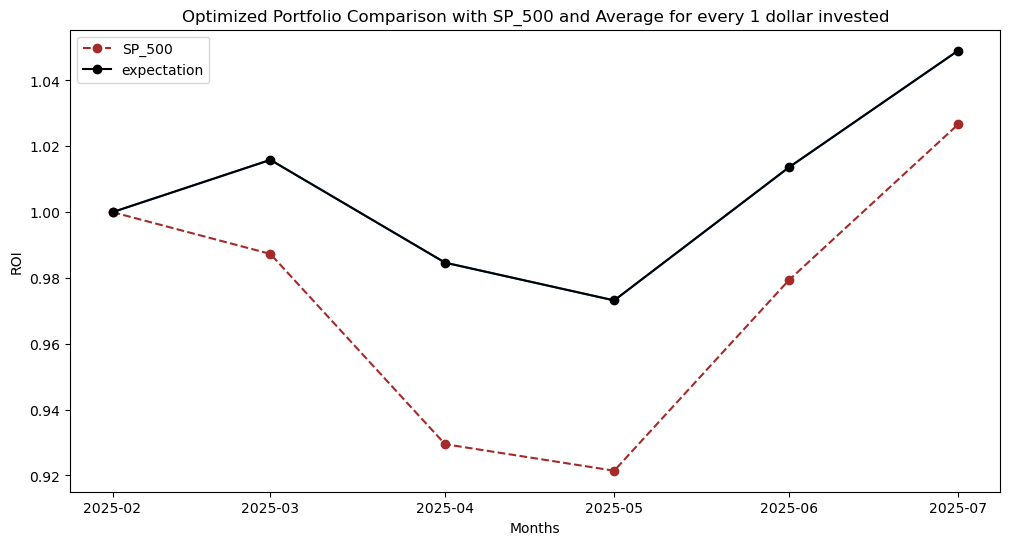

In [92]:
# MUST RUN THIS TO SET DATA !

total_value = 1000000.0

constrained_holdings = pd.DataFrame(
    [{"Ticker": "AAPL", "Value": 30000.0}, {"Ticker": "PLTR", "Value": 100000.0}]
)
constrained_holdings = None
# Shape: (2, 2)
target_mkt, target_smb, target_hml = 0.8, -0.3, 0.3


today = pd.Timestamp.now()
target_date = today.replace(day=1)
target_date = target_date.normalize()
curr_weights = target_date.date()
end1 = curr_weights - relativedelta(days=1)

oos1_list, oos1_avg, oos1_y = monte_carlo_simulation_rlm(
    1, target_mkt, target_smb, target_hml, "front", 5, 1, "m", 0, months_after_this[4]
)
final_visual()

In [185]:

today = pd.Timestamp.now()
target_date = today.replace(day=1)
target_date = target_date.normalize()
curr_weights = target_date.date()
weights_opt_d = curr_weights - relativedelta(days=1) - relativedelta(years=1)
for obj in OBJECTIVES:
    path = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{weights_opt_d.strftime('%Y-%m-%d')}.csv"
    df = pd.read_csv(path)
    curr_df = df.sort_values(by='reward')
    print(curr_df)

      c1   c2   c3    reward
216  0.7 -0.3 -0.5 -0.002427
4    1.0  0.1  0.0 -0.001995
256  1.0 -0.3 -0.6 -0.001491
236  0.7 -0.3 -0.6 -0.001385
275  1.1 -0.3 -0.6 -0.001315
..   ...  ...  ...       ...
56   1.2 -0.5  0.6  0.019829
29   1.0 -0.6  0.5  0.020361
34   0.9 -0.6  0.6  0.020604
41   1.3 -0.6  0.6  0.021151
36   1.0 -0.6  0.6  0.021750

[304 rows x 4 columns]
      c1   c2   c3    reward
216  0.7 -0.3 -0.5 -0.076275
4    1.0  0.1  0.0 -0.001972
256  1.0 -0.3 -0.6  0.053770
275  1.1 -0.3 -0.6  0.066620
5    1.0  0.0 -0.1  0.077518
..   ...  ...  ...       ...
155  0.7 -0.6 -0.2  3.104449
138  0.8 -0.6  0.1  3.145995
148  0.8 -0.6 -0.1  3.149597
143  0.8 -0.6  0.0  3.227750
150  0.7 -0.6 -0.1  3.368901

[304 rows x 4 columns]
      c1   c2   c3     reward
216  0.7 -0.3 -0.5  -0.112224
4    1.0  0.1  0.0  -0.003253
256  1.0 -0.3 -0.6   0.081231
275  1.1 -0.3 -0.6   0.102978
236  0.7 -0.3 -0.6   0.124178
..   ...  ...  ...        ...
148  0.8 -0.6 -0.1  16.281783
150  0.7 -0.6 -0

In [206]:
def get_betas():
    OBJECTIVES = ["max_return", "sharpe", "sortino", "volatility", "downside_vol"]
    betas = {}

    today = pd.Timestamp.now()
    target_date = today.replace(day=1)
    target_date = target_date.normalize()
    curr_weights = target_date.date()
    weights_opt_d = curr_weights - relativedelta(days=1) - relativedelta(years=1)

    for obj in OBJECTIVES:
        path = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{weights_opt_d.strftime('%Y-%m-%d')}.csv"
        df = pd.read_csv(path)
        curr_df = df.sort_values(by='reward')
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]
    
        betas[obj] = [betaA,betaB,betaC]
    
    return betas
betas = get_betas()

max_return
Yay!
sharpe
Yay!
sortino
Yay!
volatility
downside_vol


In [207]:
betas

{'max_return': [1.0, -0.6, 0.6],
 'sharpe': [0.7, -0.6, -0.1],
 'sortino': [0.8, -0.6, -0.3],
 'volatility': [1.3, -0.3, 0.6],
 'downside_vol': [0.7, -0.5, 0.6]}

In [174]:
today = pd.Timestamp.now()
target_date = today.replace(day=1)
target_date = target_date.normalize()
curr_weights = target_date.date()
end1 = curr_weights - relativedelta(days=1)
end1

datetime.date(2026, 2, 28)

In [175]:
end1.strftime("%Y-%m-%d")

'2026-02-28'

In [228]:
# MUST RUN THIS TO SET DATA !

total_value = 1000000.0

constrained_holdings = pd.DataFrame(
    [{"Ticker": "AAPL", "Value": 30000.0}, {"Ticker": "PLTR", "Value": 100000.0}]
)
constrained_holdings = None
# Shape: (2, 2)
target_mkt,target_smb,target_hml = 0.8, -0.3, 0.3


today = pd.Timestamp.now()
target_date = today.replace(day=1)
target_date = target_date.normalize()
curr_weights = target_date.date()
end1 = curr_weights - relativedelta(days=1)
oos1_list, oos1_avg, oos1_y = monte_carlo_simulation(
    1,
    target_mkt,
    target_smb,
    target_hml,
    end1,
    3,
    1,
    total_value,
    "m",
    constrained_holdings,
)
final_visual()

TypeError: monte_carlo_simulation() missing 1 required positional argument: 'obj_key'

In [123]:
#### CLEANED IT WITH CLAUDE + ADDED MULTI-OBJECTIVE LOGIC ###

OBJECTIVES = ["max_return", "sharpe", "sortino", "volatility", "downside_vol"]
OBJ_ORDER  = OBJECTIVES  # run in this order so each seeds the next

class AdaptiveBandit:
    def __init__(self, dateaa, objective):
        self.objective  = objective.lower()
        self.dateaa     = dateaa
        self.best_combo = np.array([1.0, 0.0, 0.0])
        self.best_score = -np.inf

        self.storage = {}          # obj -> DataFrame
        self.storage_files = {}    # obj -> filepath

        for obj in OBJECTIVES:
            # os.makedirs(obj, exist_ok=True)
            fpath = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{dateaa.strftime('%Y-%m-%d')}.csv"
            self.storage_files[obj] = fpath
            self.storage[obj] = self._load(fpath)

    # ------------------------------------------------------------------ I/O
    def _load(self, fpath):
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            df[['c1','c2','c3','reward']] = df[['c1','c2','c3','reward']].astype(float)
            return df
        return pd.DataFrame(columns=['c1','c2','c3','reward'])

    def _flush(self, obj):
        self.storage[obj].to_csv(self.storage_files[obj], index=False)

    # --------------------------------------------------------------- helpers
    def _round(self, combo):
        return np.round(np.array(combo, dtype=float), 1)

    def _check(self, combo, obj=None):
        obj = obj or self.objective
        combo = self._round(combo)
        df = self.storage[obj]
        m = df[(df.c1 == combo[0]) & (df.c2 == combo[1]) & (df.c3 == combo[2])]
        return m.iloc[0]['reward'] if not m.empty else None

    def _save(self, combo, rewards: dict):
        """Save one combo's rewards to every objective store at once."""
        combo = self._round(combo)
        for obj, reward in rewards.items():
            if self._check(combo, obj) is not None:
                continue
            row = pd.DataFrame([{'c1': combo[0], 'c2': combo[1],
                                  'c3': combo[2], 'reward': float(reward)}])
            self.storage[obj] = pd.concat([self.storage[obj], row], ignore_index=True)
            self._flush(obj)

    # ----------------------------------------------------------- simulation
    def _simulate(self, combo):
        combo = self._round(combo)
        oos1_list, _, _ = monte_carlo_simulation_rlm(
            2, combo[0], combo[1], combo[2],
            "front", 5, 1, "m", 0, self.dateaa
        )
        return final_visuala(oos1_list)

    def _score_all(self, simulated_df):
        """Score one simulated_df against every objective."""
        n = len(simulated_df)
        w = np.array([0.1, 0.15, 0.2, 0.25, 0.3])[-(n - 1):]
        w /= w.sum()

        returns_spy = simulated_df['SP_500'].pct_change().dropna()
        returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()
        rf = ff3_monthly.loc[ff3_monthly.index.isin(returns_opt.index), 'RF']
        rf = rf.reindex(returns_opt.index).fillna(rf.mean())

        rewards = {}

        # max_return
        monthly_excess = returns_opt.values - returns_spy.values
        rewards['max_return'] = float(np.dot(w, monthly_excess))

        # sharpe
        exc = returns_opt.values - rf.values
        wm  = np.dot(w, exc)
        ws  = np.sqrt(np.dot(w, (exc - wm) ** 2))
        rewards['sharpe'] = float((wm / ws) * np.sqrt(12)) if ws > 0 else 0.0

        # sortino
        down_penalty = np.sqrt(np.dot(w, np.minimum(exc, 0) ** 2)) * np.sqrt(12)
        up_capture   = np.dot(w, exc) * np.sqrt(12)

        if down_penalty < 1e-4:
            rewards['sortino'] = float(up_capture * 25)  # 0.055 * 25 = 1.37 — lands mid-range
        else:
            rewards['sortino'] = float(up_capture - (1.5 * down_penalty))
        # volatility
        vs = np.sqrt(np.dot(w, (returns_spy.values - np.dot(w, returns_spy.values)) ** 2)) * np.sqrt(12)
        vo = np.sqrt(np.dot(w, (returns_opt.values - np.dot(w, returns_opt.values)) ** 2)) * np.sqrt(12)
        rewards['volatility'] = float(vs / vo) if vo > 0 else 0.0

        # downside_vol
        spy_down = np.sqrt(np.dot(w, np.minimum(returns_spy.values, 0) ** 2)) * np.sqrt(12)
        opt_down = np.sqrt(np.dot(w, np.minimum(returns_opt.values, 0) ** 2)) * np.sqrt(12)
        base_ret = np.dot(w, returns_opt.values - returns_spy.values)

        if spy_down < 1e-4 and opt_down < 1e-4:
            rewards['downside_vol'] = float(base_ret * 25)  # same scale logic
        elif spy_down < 1e-4:
            rewards['downside_vol'] = float(base_ret - opt_down)
        else:
            rewards['downside_vol'] = float((spy_down / opt_down) + base_ret * 0.5)

        return rewards

    def _evaluate(self, combo):
        """Run simulator, score all objectives. Returns rewards dict or None on error."""
        try:
            sim = self._simulate(combo)
            return self._score_all(sim)
        except Exception as e:
            print(f"  [skip] {self._round(combo)} failed: {e}")
            return None

    # --------------------------------------------------------- bandit logic
    def _hillclimb(self):
        lo = np.array([0.7, -0.6, -0.6])
        hi = np.array([1.3,  0.6,  0.6])
        best_local = (self.best_combo, self.best_score)

        for i in range(3):
            for delta in (-0.1, 0.1):
                candidate = self.best_combo.copy()
                candidate[i] += delta
                candidate = self._round(np.clip(candidate, lo, hi))

                if self._check(candidate) is not None:
                    continue

                rewards = self._evaluate(candidate)
                if rewards is None:
                    continue

                self._save(candidate, rewards)
                if rewards[self.objective] > best_local[1]:
                    best_local = (candidate, rewards[self.objective])

        self.best_combo, self.best_score = best_local

    def run_bandit(self, iterations, hot_start_storage=None):
        print(f"\n── {self.objective} | {self.dateaa.strftime('%Y-%m-%d')} ──")

        # Seed from previous objective's explored combos if provided
        if hot_start_storage is not None and not hot_start_storage.empty:
            top = hot_start_storage.nlargest(1, 'reward').iloc[0]
            base = np.array([top.c1, top.c2, top.c3])
            print(f"  Hot start from prior objective: {base}")
        else:
            base = np.array([1.0, 0.0, 0.0])

        # Evaluate base if unseen
        if self._check(base) is None:
            rewards = self._evaluate(base)
            if rewards is not None:
                self._save(base, rewards)

        self.best_combo = base
        self.best_score = self._check(base) or 0.0
        print(f"  Base: {self.best_combo} → {self.best_score:.4f}")

        saved_start  = len(self.storage[self.objective])
        attempt_cap  = iterations + 50

        while (len(self.storage[self.objective]) - saved_start) < iterations and attempt_cap > 0:
            attempt_cap -= 1

            self._hillclimb()

            # random perturbation around current best
            rand = self._round(np.clip(
                self.best_combo + np.random.uniform(-0.3, 0.3, 3),
                [0.7, -0.6, -0.6], [1.3, 0.6, 0.6]
            ))

            if self._check(rand) is None:
                rewards = self._evaluate(rand)
                if rewards is None:
                    continue
                else:
                    self._save(rand, rewards)
                    if rewards[self.objective] > self.best_score:
                        self.best_score = rewards[self.objective]
                        self.best_combo = rand

                n = len(self.storage[self.objective]) - saved_start
                print(f"  [{n:>3}] {rand} → {self.best_score:.4f}")

        if attempt_cap == 0:
            n = len(self.storage[self.objective]) - saved_start
            print(f"  WARNING: attempt_cap hit — {n}/{iterations} completed")

        print(f"  Best: {self.best_combo} → {self.best_score:.4f}")
        return self.storage[self.objective]   # hand off to next objective


# ------------------------------------------------------------------ main loop
for i in range(len(months_after_this)):
    # seed prev_storage from max_return's existing CSV if it has data
    first_obj = OBJ_ORDER[0]
    dateaa = months_after_this[i]
    first_fpath = f"Front_End_Strategies/{first_obj}/rebal_explored_{first_obj}_active_{dateaa.strftime('%Y-%m-%d')}.csv"

    if os.path.exists(first_fpath):
        prev_storage = pd.read_csv(first_fpath)
        prev_storage[["c1", "c2", "c3", "reward"]] = prev_storage[
            ["c1", "c2", "c3", "reward"]
        ].astype(float)
    else:
        prev_storage = None

    for obj in OBJ_ORDER:
        bandit = AdaptiveBandit(dateaa, objective=obj)
        prev_storage = bandit.run_bandit(iterations=150, hot_start_storage=prev_storage)


── max_return | 2025-02-28 ──
  Hot start from prior objective: [ 1.  -0.6  0.6]
  Base: [ 1.  -0.6  0.6] → 0.0217
  Best: [ 1.  -0.6  0.6] → 0.0217

── sharpe | 2025-02-28 ──
  Hot start from prior objective: [ 1.  -0.6  0.6]
  Base: [ 1.  -0.6  0.6] → 2.6106
  Best: [ 1.  -0.6  0.6] → 2.6106

── sortino | 2025-02-28 ──
  Hot start from prior objective: [ 0.7 -0.6 -0.1]
  Base: [ 0.7 -0.6 -0.1] → 16.3482
Testing // Input Dates: 2021-10-01 00:00:00 - 2024-09-30 00:00:00
Validation  // Output Dates: 2024-10-01 00:00:00 - 2024-11-01 00:00:00
Testing // Input Dates: 2021-11-01 00:00:00 - 2024-10-30 00:00:00
Validation  // Output Dates: 2024-11-01 00:00:00 - 2024-12-01 00:00:00
Testing // Input Dates: 2021-12-01 00:00:00 - 2024-11-30 00:00:00
Validation  // Output Dates: 2024-12-01 00:00:00 - 2025-01-01 00:00:00
Testing // Input Dates: 2022-01-01 00:00:00 - 2024-12-30 00:00:00
Validation  // Output Dates: 2025-01-01 00:00:00 - 2025-02-01 00:00:00
Testing // Input Dates: 2022-02-01 00:00:0

KeyboardInterrupt: 

In [135]:
num = [1,9]
for i in num:
    oos1_list, _, _ = monte_carlo_simulation_rlm(
                2, .9, .3, .1,
                "front", 5, 1, "m", 0, months_after_this[i]
            )
    # run on a known good month to calibrate
    simulated_df = final_visuala(oos1_list)
    n = len(simulated_df)
    w = np.array([0.1, 0.15, 0.2, 0.25, 0.3])[-(n - 1) :]
    w /= w.sum()

    returns_spy = simulated_df["SP_500"].pct_change().dropna()
    returns_opt = simulated_df["Optimized Portfolio"].pct_change().dropna()
    rf = ff3_monthly.loc[ff3_monthly.index.isin(returns_opt.index), "RF"]
    rf = rf.reindex(returns_opt.index).fillna(rf.mean())

    exc = returns_opt.values - rf.values
    wm = np.dot(w, exc)

    down_penalty = np.sqrt(np.dot(w, np.minimum(exc, 0) ** 2)) * np.sqrt(12)
    up_capture = np.dot(w, exc) * np.sqrt(12)
    spy_down = np.sqrt(np.dot(w, np.minimum(returns_spy.values, 0) ** 2)) * np.sqrt(12)
    opt_down = np.sqrt(np.dot(w, np.minimum(returns_opt.values, 0) ** 2)) * np.sqrt(12)
    base_ret = np.dot(w, returns_opt.values - returns_spy.values)

    print(f"up_capture:   {up_capture:.6f}")
    print(f"down_penalty: {down_penalty:.6f}")
    print(f"spy_down:     {spy_down:.6f}")
    print(f"opt_down:     {opt_down:.6f}")
    print(f"base_ret:     {base_ret:.6f}")

up_capture:   -0.076169
down_penalty: 0.143840
spy_down:     0.118107
opt_down:     0.134066
base_ret:     -0.005117
up_capture:   0.054587
down_penalty: 0.000000
spy_down:     0.000000
opt_down:     0.000000
base_ret:     0.000666


In [165]:
months_after_this

{0: Timestamp('2025-02-28 00:00:00'),
 1: Timestamp('2025-03-31 00:00:00'),
 2: Timestamp('2025-04-30 00:00:00'),
 3: Timestamp('2025-05-31 00:00:00'),
 4: Timestamp('2025-06-30 00:00:00'),
 5: Timestamp('2025-07-31 00:00:00'),
 6: Timestamp('2025-08-31 00:00:00'),
 7: Timestamp('2025-09-30 00:00:00'),
 8: Timestamp('2025-10-31 00:00:00'),
 9: Timestamp('2025-11-30 00:00:00'),
 10: Timestamp('2025-12-31 00:00:00'),
 11: Timestamp('2026-01-31 00:00:00'),
 12: Timestamp('2026-02-28 00:00:00')}

In [168]:
pa = f"Front_End_Strategies/downside_vol/rebal_explored_downside_vol_active_2025-11-30.csv"
df1 = pd.read_csv(pa)
len(df1)

0

In [ ]:
m

In [172]:
for i in range(len(months_after_this)):
    m = months_after_this[i]
    # Check which objectives need initialization
    needs_init = []
    for obj in OBJECTIVES:
        fpath = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{m.strftime('%Y-%m-%d')}.csv"
        if not os.path.exists(fpath) or pd.read_csv(fpath).empty:
            needs_init.append(obj)

    if not needs_init:
        continue

    # Only run the simulation if at least one objective needs a row
    oos1_list, _, _ = monte_carlo_simulation_rlm(2, 1, 0, 0, "front", 5, 1, "m", 0, m)
    simulated_df = final_visuala(oos1_list)
    n = len(simulated_df)
    w = np.array([0.1, 0.15, 0.2, 0.25, 0.3])[-(n - 1) :]
    w /= w.sum()

    returns_spy = simulated_df["SP_500"].pct_change().dropna()
    returns_opt = simulated_df["Optimized Portfolio"].pct_change().dropna()
    rf = ff3_monthly.loc[ff3_monthly.index.isin(returns_opt.index), "RF"]
    rf = rf.reindex(returns_opt.index).fillna(rf.mean())

    rewards = {}

    monthly_excess = returns_opt.values - returns_spy.values
    rewards["max_return"] = float(np.dot(w, monthly_excess))

    exc = returns_opt.values - rf.values
    wm = np.dot(w, exc)
    ws = np.sqrt(np.dot(w, (exc - wm) ** 2))
    rewards["sharpe"] = float((wm / ws) * np.sqrt(12)) if ws > 0 else 0.0

    down_penalty = np.sqrt(np.dot(w, np.minimum(exc, 0) ** 2)) * np.sqrt(12)
    up_capture = np.dot(w, exc) * np.sqrt(12)
    rewards["sortino"] = (
        float(up_capture * 25)
        if down_penalty < 1e-4
        else float(up_capture - (1.5 * down_penalty))
    )

    vs = np.sqrt(
        np.dot(w, (returns_spy.values - np.dot(w, returns_spy.values)) ** 2)
    ) * np.sqrt(12)
    vo = np.sqrt(
        np.dot(w, (returns_opt.values - np.dot(w, returns_opt.values)) ** 2)
    ) * np.sqrt(12)
    rewards["volatility"] = float(vs / vo) if vo > 0 else 0.0

    spy_down = np.sqrt(np.dot(w, np.minimum(returns_spy.values, 0) ** 2)) * np.sqrt(12)
    opt_down = np.sqrt(np.dot(w, np.minimum(returns_opt.values, 0) ** 2)) * np.sqrt(12)
    base_ret = np.dot(w, returns_opt.values - returns_spy.values)
    if spy_down < 1e-4 and opt_down < 1e-4:
        rewards["downside_vol"] = float(base_ret * 25)
    elif spy_down < 1e-4:
        rewards["downside_vol"] = float(base_ret - opt_down)
    else:
        rewards["downside_vol"] = float((spy_down / opt_down) + base_ret * 0.5)

    for obj in needs_init:
        row = pd.DataFrame(
            [{"c1": 1.0, "c2": 0.0, "c3": 0.0, "reward": float(rewards[obj])}]
        )
        fpath = f"Front_End_Strategies/{obj}/rebal_explored_{obj}_active_{m.strftime('%Y-%m-%d')}.csv"
        row.to_csv(fpath, index=False)
        print(f"Initialized {obj} for {m.strftime('%Y-%m')}")

Initialized downside_vol for 2025-09
Initialized downside_vol for 2025-10
Initialized downside_vol for 2025-11
Initialized max_return for 2026-01
Initialized sharpe for 2026-01
Initialized sortino for 2026-01
Initialized volatility for 2026-01
Initialized downside_vol for 2026-01
Initialized max_return for 2026-02
Initialized sharpe for 2026-02
Initialized sortino for 2026-02
Initialized volatility for 2026-02
Initialized downside_vol for 2026-02
